# CLIP 복습과제 — 전이 학습에서 zero-shot까지
**논문** Radford et al., *Learning Transferable Visual Models From Natural Language Supervision* (ICML 2021) · **교재** 서지영, 《딥러닝 파이토치 교과서》 5.3 전이 학습 (p.200~228)

교재 5.3.1의 **특성 추출 기법**은 사전 학습된 합성곱층을 고정하고 마지막 완전연결층만 새로 학습합니다.
CLIP 논문은 바로 이 방식(논문에서는 **linear probe**)으로 표현을 평가하고, 한 걸음 더 나아가 **마지막 층의 가중치를 학습하지 않고 클래스 이름 문장으로 만들어 내는 zero-shot 분류**를 보여 줍니다.
이번 과제에서는 교재 코드를 재현한 뒤, 같은 자리에 CLIP을 넣어 논문 2~3장의 핵심 결과를 작은 규모로 직접 확인합니다.

| 파트 | 내용 | 교재 · 논문 연결 |
|---|---|---|
| **Part 1** | ResNet18 특성 추출로 개 vs 고양이 분류 | 교재 코드 5-12 ~ 5-29 |
| **Part 2** | CLIP 대조 손실(symmetric InfoNCE) 직접 구현 | 논문 2.3절, Figure 3 |
| **Part 3** | CLIP zero-shot 분류 + prompt engineering | 논문 3.1.2 ~ 3.1.4절, Figure 4 |
| **Part 4** | linear probe와 few-shot vs zero-shot 비교 | 교재 5.3.1 = 논문 3.2절, Figure 6 · 7 |
| **Part 5** | 서술형 문제 | 논문 2 · 3장 |

**진행 방법**
- 상단 메뉴 **런타임 → 런타임 유형 변경 → T4 GPU**를 선택한 뒤 위에서부터 차례로 실행합니다.
- 코드의 `________` 빈칸을 채우세요. 빈칸 옆 TODO 주석에 번호(①~⑰)와 힌트가 있습니다. 빈칸 뒤의 **✅ 확인 셀**이 통과하면 맞게 채운 것입니다.
- 데이터셋은 **Oxford-IIIT Pet** (37개 품종, 학습 3,680장 · 테스트 3,669장)을 씁니다. 교재의 개·고양이 데이터와 같은 문제이고, CLIP 논문의 zero-shot 평가(Figure 5)와 **사람 vs CLIP 비교 실험(4장, Table 2)** 에 쓰인 바로 그 데이터셋입니다.
- 예상 소요 시간: 데이터 다운로드 포함 약 60~90분

**제출** 코드 · 실행 결과 · 주석이 모두 남아 있는 `.ipynb` 파일 (파일명 · PR 제목 · 라벨 · 브랜치 규칙은 기존 복습과제와 동일)

In [19]:
# 0. 환경 설정 — Colab에는 torch, torchvision, transformers, scikit-learn이 기본으로 설치되어 있습니다.
import os, time, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| device:", device)

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(42)

torch 2.11.0+cu130 | torchvision 0.26.0+cu130 | device: cuda


---
## Part 1. 교재 재현 — 특성 추출 기법 (교재 5.3.1, 코드 5-12 ~ 5-29)

교재는 Kaggle 개·고양이 사진 일부(학습 385장, 테스트 98장)를 사용했습니다. 여기서는 같은 개 vs 고양이 문제를 **Oxford-IIIT Pet**으로 풉니다.
`target_types="binary-category"`로 불러오면 라벨이 **0 = Cat, 1 = Dog**가 되어 교재의 `classes = {0:'cat', 1:'dog'}`와 같은 구성이 됩니다. *(torchvision 0.16 이상 필요 · Colab 기본 버전이면 충분)*

> 데이터셋 다운로드(약 800MB)에 1~3분 정도 걸립니다.

In [20]:
# 1-1. 데이터 불러오기와 전처리 (교재 코드 5-13, 5-23 대응)
data_root = "./data"

# ImageNet으로 사전 학습된 ResNet18의 입력 분포에 맞추는 정규화 값
# (교재 코드에는 Normalize가 없지만, 사전 학습 때와 같은 분포로 맞춰 주면 결과가 더 안정적입니다)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize([256, 256]),        # ⓐ 크기를 256×256으로 조정
    transforms.RandomResizedCrop(224),    # ⓑ 데이터 확장: 랜덤한 크기·비율로 자른 뒤 224×224로
    transforms.RandomHorizontalFlip(),    # ⓒ 데이터 확장: 좌우 반전
    transforms.ToTensor(),                # ⓓ PIL 이미지 → 텐서
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_bin = torchvision.datasets.OxfordIIITPet(data_root, split="trainval", target_types="binary-category",
                                               transform=train_transform, download=True)
test_bin = torchvision.datasets.OxfordIIITPet(data_root, split="test", target_types="binary-category",
                                              transform=test_transform, download=True)

train_loader = DataLoader(train_bin, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_bin, batch_size=64, shuffle=False, num_workers=2)
print("학습 데이터:", len(train_bin), "장 | 테스트 데이터:", len(test_bin), "장")

학습 데이터: 3680 장 | 테스트 데이터: 3669 장


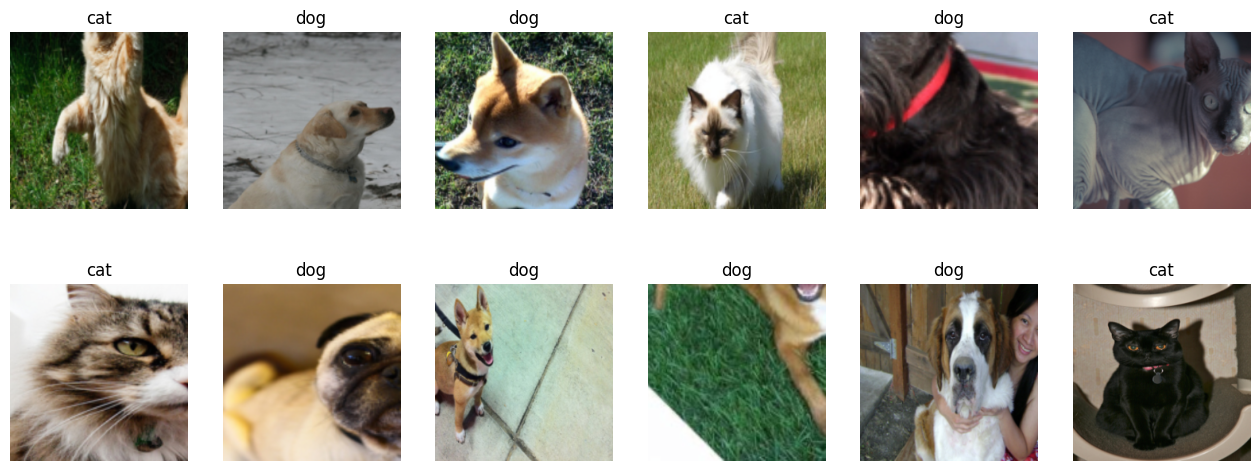

In [21]:
# 1-2. 학습에 사용될 이미지 출력 (교재 코드 5-14, 5-28 대응)
classes_bin = {0: "cat", 1: "dog"}

def im_convert(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    # 교재 코드 5-28: clone().detach()로 기울기와 분리한 복사본을 만든 뒤 (C,H,W) → (H,W,C)
    image = tensor.clone().detach().cpu().numpy().transpose(1, 2, 0)
    image = image * np.array(std) + np.array(mean)   # 정규화 되돌리기
    return image.clip(0, 1)

samples, labels = next(iter(train_loader))
fig = plt.figure(figsize=(16, 6))
for i in range(12):
    ax = fig.add_subplot(2, 6, i + 1)
    ax.set_title(classes_bin[labels[i].item()])
    ax.axis("off")
    ax.imshow(im_convert(samples[i]))
plt.show()

### 문제 1-1. 사전 학습된 ResNet18의 합성곱층을 고정하고, 새 완전연결층만 학습되게 만드세요 (교재 코드 5-15 ~ 5-19, 5-21)
- 교재의 `models.resnet18(pretrained=True)`는 최신 torchvision에서 `weights=` 인자로 바뀌었습니다.
- ① 역전파 때 기울기를 계산하지 않도록 파라미터를 고정하고, ② 마지막 `fc` 층을 **입력 512, 출력 2**인 새 층으로 바꾸고, ③ 옵티마이저에는 **학습할 파라미터만** 넘깁니다.

In [22]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)   # 교재: models.resnet18(pretrained=True)

def set_parameter_requires_grad(model, feature_extracting=True):      # 교재 코드 5-16
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False          # TODO ① 합성곱층 가중치 고정

set_parameter_requires_grad(resnet18)
resnet18.fc = nn.Linear(512,2)                  # TODO ② 새 분류기: 입력 512, 클래스 2개 (교재 코드 5-17)
resnet18 = resnet18.to(device)

params_to_update = [p for p in resnet18.parameters() if p.requires_grad]   # 교재 코드 5-21
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print("\t학습되는 파라미터:", name)

optimizer = torch.optim.Adam(params_to_update)   # TODO ③ 학습할 파라미터만 전달
criterion = nn.CrossEntropyLoss()

	학습되는 파라미터: fc.weight
	학습되는 파라미터: fc.bias


In [23]:
# ✅ 확인 셀
n_trainable = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print("학습되는 파라미터 수:", n_trainable)
assert n_trainable == 512 * 2 + 2, "fc 층(가중치 512×2 + 편향 2)만 학습되어야 합니다."
assert resnet18.fc.out_features == 2
print("✅ 통과")

학습되는 파라미터 수: 1026
✅ 통과


### 문제 1-2. 학습 함수와 평가 함수를 완성하세요 (교재 코드 5-20, 5-24)
교재의 학습 함수에서 핵심 세 줄(기울기 초기화 → 역전파 → 갱신) 중 두 줄과, 평가에서 예측 클래스를 고르는 부분을 채웁니다.

In [24]:
def train_model(model, dataloader, criterion, optimizer, device, num_epochs=3):
    since = time.time()
    acc_history, loss_history = [], []
    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()                  # 기울기를 0으로 초기화
            outputs = model(inputs)                # 순전파
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()                       # TODO ④ 역전파
            optimizer.step()                # TODO ⑤ 파라미터 갱신

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).item()

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects / len(dataloader.dataset)
        print(f"Epoch {epoch}/{num_epochs - 1}  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")
        acc_history.append(epoch_acc)
        loss_history.append(epoch_loss)

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    return acc_history, loss_history


@torch.no_grad()                                   # 교재 코드 5-24의 with torch.no_grad()와 같은 역할
def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)            # TODO ⑥ 가장 큰 로짓의 인덱스 = 예측 클래스
        correct += (preds == labels).sum().item()
    return correct / len(dataloader.dataset)

Epoch 0/2  Loss: 0.2261  Acc: 0.9103
Epoch 1/2  Loss: 0.1467  Acc: 0.9410
Epoch 2/2  Loss: 0.1162  Acc: 0.9546
Training complete in 2m 26s

테스트 정확도 (ResNet18 특성 추출, 개 vs 고양이): 0.9815


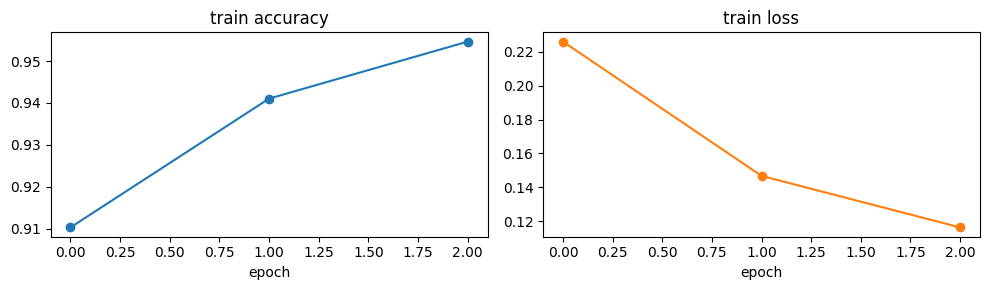

✅ 통과


In [25]:
# 1-3. 학습과 평가 (교재 코드 5-22, 5-25) — T4 GPU 기준 에포크당 30초 안팎
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device, num_epochs=3)
test_acc_bin = evaluate(resnet18, test_loader, device)
print(f"\n테스트 정확도 (ResNet18 특성 추출, 개 vs 고양이): {test_acc_bin:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))                # 교재 코드 5-26, 5-27
axes[0].plot(train_acc_hist, marker="o"); axes[0].set_title("train accuracy"); axes[0].set_xlabel("epoch")
axes[1].plot(train_loss_hist, marker="o", color="tab:orange"); axes[1].set_title("train loss"); axes[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

assert test_acc_bin > 0.9, "정확도가 90%보다 낮다면 빈칸 ④⑤⑥을 다시 확인하세요."
print("✅ 통과")

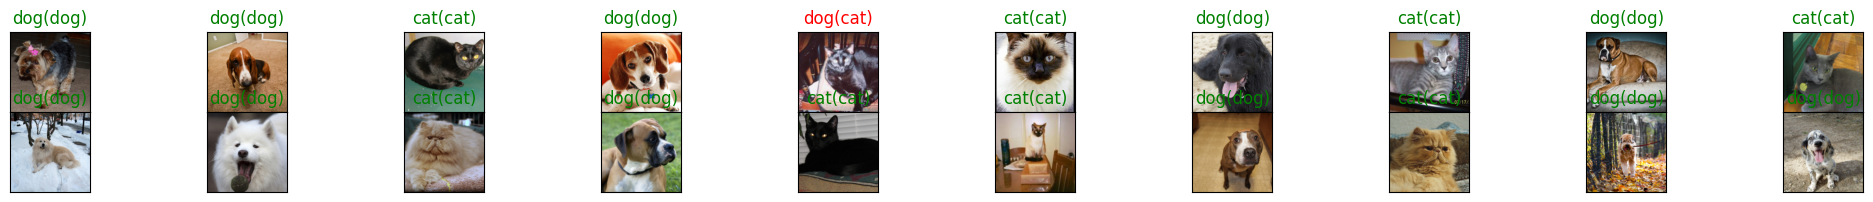

In [26]:
# 1-4. 개와 고양이 예측 결과 출력 (교재 코드 5-29) — 초록: 정답, 빨강: 오답
images, labels = next(iter(DataLoader(test_bin, batch_size=20, shuffle=True)))
with torch.no_grad():
    preds = resnet18(images.to(device)).argmax(1).cpu()
fig = plt.figure(figsize=(25, 4))
for idx in range(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks=[], yticks=[])
    ax.imshow(im_convert(images[idx]))
    ax.set_title(f"{classes_bin[preds[idx].item()]}({classes_bin[labels[idx].item()]})",
                 color=("green" if preds[idx] == labels[idx] else "red"))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)
plt.show()

### 문제 1-3 (서술형). 위 모델에서 실제로 학습된 파라미터는 몇 개이고, 나머지 약 1,100만 개의 파라미터는 무엇을 하고 있었나요? 이 방식을 CLIP 논문에서는 무엇이라고 부르나요?

**답:**

실제로 학습된 파라미터는 마지막 fc 층의 가중치 512×2=1,024개와 편향 2개를 합한 1,026개입니다. 나머지 약 1,100만 개의 파라미터는 고정된 상태로, 입력 이미지에서 특징을 추출해 512차원 특징 벡터로 변환하는 역할을 했습니다.

CLIP 논문에서는 이처럼 특징 추출기는 고정하고 그 위의 선형 분류기만 학습하여 표현의 품질을 평가하는 방식을 linear probe라고 부릅니다.

---
## Part 2. CLIP의 대조 손실 직접 구현하기 (논문 2.3절, Figure 3)

배치에 (이미지, 텍스트) 쌍이 $N$개 있을 때, CLIP은 $N \times N$개의 조합 중 **실제 짝인 대각선 $N$개**의 유사도는 높이고 나머지 $N^2-N$개는 낮춥니다.

$$s_{ij} = \frac{\langle \mathbf{I}_i, \mathbf{T}_j \rangle}{\tau}, \qquad
\mathcal{L}_{I\rightarrow T} = -\frac{1}{N}\sum_{i=1}^{N}\log\frac{\exp(s_{ii})}{\sum_{j=1}^{N}\exp(s_{ij})}, \qquad
\mathcal{L} = \tfrac{1}{2}\left(\mathcal{L}_{I\rightarrow T} + \mathcal{L}_{T\rightarrow I}\right)$$

논문 Figure 3의 의사코드:
```python
I_e = l2_normalize(np.dot(I_f, W_i), axis=1)
T_e = l2_normalize(np.dot(T_f, W_t), axis=1)
logits = np.dot(I_e, T_e.T) * np.exp(t)          # exp(t) = 1/τ
labels = np.arange(n)
loss_i = cross_entropy_loss(logits, labels, axis=0)
loss_t = cross_entropy_loss(logits, labels, axis=1)
loss = (loss_i + loss_t)/2
```
`F.cross_entropy(logits, labels)`는 **각 행**에 softmax를 적용합니다. 행 $i$는 '이미지 $i$가 $N$개 텍스트 중 무엇과 짝인가'이므로 이미지→텍스트 방향이고, 전치한 `logits.T`를 넣으면 텍스트→이미지 방향이 됩니다.

### 문제 2-1. `clip_loss`를 완성하세요

In [27]:
def clip_loss(I_e, T_e, t):
    # I_e : [n, d_e] 이미지 임베딩,  T_e : [n, d_e] 텍스트 임베딩 (i번째끼리 짝)
    # t   : 스칼라 텐서. 논문 Figure 3의 t (exp(t) = 1/τ, 학습되는 온도의 역수를 로그로 표현한 값)
    I_e = F.normalize(I_e, dim=1)                                    # l2_normalize
    T_e = F.normalize(T_e, dim=1)
    logits = I_e @ T_e.T * t.exp()     # TODO ⑦ [n, n] 스케일된 코사인 유사도
    labels = torch.arange(I_e.size(0), device=I_e.device)          # TODO ⑧ 정답은 언제나 대각선
    loss_i2t = F.cross_entropy(logits, labels)                       # 행 방향: 이미지 → 텍스트
    loss_t2i = F.cross_entropy(logits.T, labels)                    # TODO ⑨ 열 방향: 텍스트 → 이미지
    return (loss_i2t + loss_t2i) / 2

In [28]:
# ✅ 확인 셀
torch.manual_seed(0)
n, d = 8, 16
I = torch.randn(n, d)
T = torch.randn(n, d)
t = torch.tensor(np.log(1 / 0.07))                 # 논문 2.5절: τ의 초깃값 0.07

loss_random = clip_loss(I, T, t)                     # 짝이 무작위인 경우
loss_aligned = clip_loss(I, I + 0.05 * torch.randn(n, d), t)   # 짝끼리 거의 같은 방향인 경우
print(f"무작위 쌍 손실: {loss_random.item():.4f}  |  정렬된 쌍 손실: {loss_aligned.item():.4f}")

assert loss_aligned < loss_random, "짝이 맞으면 손실이 더 작아야 합니다."
assert torch.allclose(clip_loss(I, T, t), clip_loss(T, I, t), atol=1e-6), "이미지와 텍스트를 바꿔도 같은 값이어야 합니다(대칭 손실)."
print("✅ 통과")

무작위 쌍 손실: 4.2291  |  정렬된 쌍 손실: 0.0003
✅ 통과


### 문제 2-2. 온도 τ가 softmax 분포를 어떻게 바꾸는지 확인하세요
같은 코사인 유사도 `[0.32, 0.28, 0.25, 0.20]`에 서로 다른 $1/\tau$를 곱해 softmax를 취합니다.
CLIP은 $\tau$를 0.07에서 시작해 학습하고, $1/\tau$가 100을 넘지 않도록 잘랐습니다 (논문 2.5절).

         1/tau = 1: [0.2645 0.2542 0.2467 0.2346]
1/tau = 14.3 (init): [0.4733 0.2673 0.1741 0.0852]
 1/tau = 100 (max): [9.811e-01 1.800e-02 9.000e-04 0.000e+00]


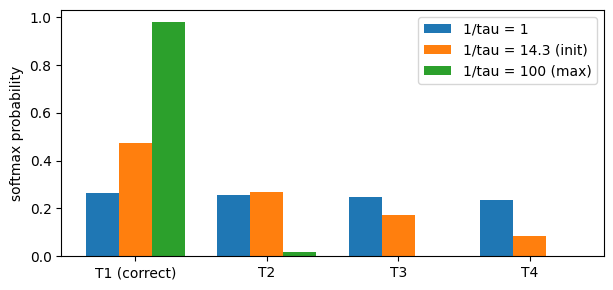

In [30]:
sims = torch.tensor([0.32, 0.28, 0.25, 0.20])        # 첫 번째가 정답 텍스트라고 가정
scales = {"1/tau = 1": 1.0, "1/tau = 14.3 (init)": 1 / 0.07, "1/tau = 100 (max)": 100.0}

fig, ax = plt.subplots(figsize=(7, 3.2))
width = 0.25
for k, (name, s) in enumerate(scales.items()):
    probs =  F.softmax(sims * s, dim=-1)             # TODO ⑩ 온도를 반영한 softmax
    ax.bar(np.arange(4) + (k - 1) * width, probs.numpy(), width, label=name)
    print(f"{name:>18s}: {np.round(probs.numpy(), 4)}")
ax.set_xticks(range(4)); ax.set_xticklabels(["T1 (correct)", "T2", "T3", "T4"])
ax.set_ylabel("softmax probability"); ax.legend(); plt.show()

### 문제 2-3 (서술형)
1. `labels = np.arange(n)`이 의미하는 바를 설명하고, 이 손실에서 **오답(negative)** 은 어디에서 오는지 쓰세요.
2. 배치 크기 $N$이 커지면 이 문제는 어떻게 달라지나요? CLIP이 배치 크기 32,768을 쓴 이유와 연결해 쓰세요.
3. 논문은 왜 $\tau$를 하이퍼파라미터로 두지 않고 학습했나요? $\tau$가 너무 크거나 작으면 각각 어떤 문제가 생길까요?

**답:**

1. labels = np.arange(n)은 정답 인덱스를 0부터 n−1까지 지정한다는 뜻이다. i번째 이미지의 정답은 i번째 텍스트이므로 유사도 행렬의 대각선이 정답이 된다. 오답은 따로 만들지 않고, 같은 배치에 있는 나머지 N−1개의 텍스트를 사용한다. 반대로 텍스트에서 이미지를 찾을 때도 동일하다.

2. 배치 크기 N이 커지면 비교할 오답이 많아져, 모델이 정답과 오답을 더 세밀하게 구분하도록 학습할 수 있다. CLIP이 배치 크기 32,768을 사용한 이유도 많은 오답을 활용하기 위해서다. 다만 N×N개의 유사도를 계산해야 하므로 연산량과 메모리 부담이 커진다.

3. τ는 정답과 오답의 확률 차이가 얼마나 뚜렷해지는지를 조절하는 값이다. 적절한 값을 미리 정하기 어려워 학습 과정에서 직접 조절하도록 했다. τ가 너무 크면 확률 분포가 평평해져 정답과 오답을 구분하는 학습 신호가 약해지고, 너무 작으면 로짓 값이 커져 학습이 불안정해질 수 있다. 그래서 CLIP은 1/τ가 100을 넘지 않도록 제한했다.

---
## Part 3. CLIP zero-shot 분류 (논문 3.1.2 ~ 3.1.4절)

이제 이미 학습된 CLIP(**ViT-B/32**, Hugging Face `openai/clip-vit-base-patch32`)으로 37개 품종을 **학습 없이** 분류합니다.

1. 클래스 이름을 프롬프트 문장에 넣어 텍스트 인코더로 임베딩합니다 → 클래스마다 벡터 하나, 즉 **분류기 가중치 $W$** ($d_e \times K$)
2. 이미지 임베딩과 $W$의 코사인 유사도에 $1/\tau$를 곱해 softmax → 가장 큰 클래스가 예측입니다.

논문은 이것을 '입력과 가중치를 L2 정규화하고 bias가 없는 **multinomial logistic regression**'이라고 해석하고, 텍스트 인코더를 분류기의 가중치를 만들어 내는 **hypernetwork**라고 부릅니다(3.1.2절).

In [31]:
# 3-1. CLIP 불러오기
from transformers import CLIPModel, AutoTokenizer

MODEL_ID = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(MODEL_ID).to(device).eval()
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print("exp(t) = 1/τ =", round(clip_model.logit_scale.exp().item(), 2))   # 논문 2.5절: 100에서 clip
print("이미지 특징 차원 d_i =", clip_model.config.vision_config.hidden_size,
      "| 텍스트 특징 차원 d_t =", clip_model.config.text_config.hidden_size,
      "| 공동 임베딩 차원 d_e =", clip_model.config.projection_dim)

# CLIP 전처리: 짧은 변 224로 bicubic 리사이즈 → 가운데 224×224 자르기 → CLIP 학습 데이터 통계로 정규화
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)
clip_transform = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

train_pet = torchvision.datasets.OxfordIIITPet(data_root, split="trainval", target_types="category",
                                               transform=clip_transform, download=True)
test_pet = torchvision.datasets.OxfordIIITPet(data_root, split="test", target_types="category",
                                              transform=clip_transform, download=True)
classnames = train_pet.classes
print(len(classnames), "classes:", classnames[:6], "...")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

exp(t) = 1/τ = 100.0
이미지 특징 차원 d_i = 768 | 텍스트 특징 차원 d_t = 512 | 공동 임베딩 차원 d_e = 512
37 classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal'] ...


### 문제 3-1. Figure 3과 똑같은 순서로 인코딩 함수를 완성하세요
- 텍스트: 트랜스포머의 **[EOS] 위치 출력**(`pooler_output`)이 $T_f$ → 선형 투영 $W_t$ → $T_e$ (논문 2.4절)
- 이미지: ViT의 [CLS] 출력(`pooler_output`)이 $I_f$ → 선형 투영 $W_i$ → $I_e$

In [32]:
@torch.no_grad()
def encode_text(texts):
    tok = tokenizer(texts, padding=True, return_tensors="pt").to(device)
    T_f = clip_model.text_model(input_ids=tok["input_ids"], attention_mask=tok["attention_mask"]).pooler_output  # [n, d_t]
    T_e = clip_model.text_projection(T_f)         # TODO ⑪ W_t로 공동 임베딩 공간에 투영 → [n, d_e]
    return F.normalize(T_e, dim=-1)


@torch.no_grad()
def encode_image_batch(pixel_values):
    I_f = clip_model.vision_model(pixel_values=pixel_values).pooler_output                # [n, d_i]
    I_e = clip_model.visual_projection(I_f)        # TODO ⑫ W_i로 공동 임베딩 공간에 투영 → [n, d_e]
    return I_f, F.normalize(I_e, dim=-1)

In [33]:
# ✅ 확인 셀: 직접 만든 인코딩이 CLIPModel 자체 forward 결과와 같은지 비교
x, _ = next(iter(DataLoader(test_pet, batch_size=4)))
texts = ["a photo of a cat.", "a photo of a dog."]
tok = tokenizer(texts, padding=True, return_tensors="pt").to(device)
with torch.no_grad():
    out = clip_model(input_ids=tok["input_ids"], attention_mask=tok["attention_mask"], pixel_values=x.to(device))
_, I_e = encode_image_batch(x.to(device))
T_e = encode_text(texts)
logits_manual = clip_model.logit_scale.exp() * I_e @ T_e.T
assert torch.allclose(I_e, out.image_embeds, atol=1e-4) and torch.allclose(T_e, out.text_embeds, atol=1e-4)
assert torch.allclose(logits_manual, out.logits_per_image, atol=1e-2)
print("✅ 통과 — logits_per_image = exp(t) · I_e · T_eᵀ")

✅ 통과 — logits_per_image = exp(t) · I_e · T_eᵀ


In [34]:
# 3-2. 이미지 특징을 한 번만 뽑아 둡니다 (Part 4에서도 재사용). T4 기준 약 1~2분
@torch.no_grad()
def extract_clip_features(dataset, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    feats_f, feats_e, ys = [], [], []
    for x, y in loader:
        I_f, I_e = encode_image_batch(x.to(device))
        feats_f.append(I_f.cpu()); feats_e.append(I_e.cpu()); ys.append(y)
    return torch.cat(feats_f), torch.cat(feats_e), torch.cat(ys)

test_If, test_Ie, test_y = extract_clip_features(test_pet)
train_If, train_Ie, train_y = extract_clip_features(train_pet)
print("I_f:", tuple(test_If.shape), "| I_e:", tuple(test_Ie.shape))

I_f: (3669, 768) | I_e: (3669, 512)


### 문제 3-2. zero-shot 분류기를 만들고 프롬프트에 따른 정확도를 비교하세요 (논문 3.1.4절, Figure 4)
- 여러 템플릿을 쓸 때는 논문처럼 **확률 공간이 아니라 임베딩 공간에서 평균**을 냅니다. 그러면 클래스마다 평균 벡터 하나만 저장하면 되므로, 예측 비용은 템플릿 하나일 때와 같습니다.

In [35]:
def build_zeroshot_weights(classnames, templates):
    weights = []
    for c in classnames:
        emb = encode_text([tpl.format(c) for tpl in templates])      # [템플릿 수, d_e]
        emb = emb.mean(dim=0)                                     # TODO ⑬ 프롬프트 앙상블: 임베딩 평균
        weights.append(F.normalize(emb, dim=-1))
    return torch.stack(weights, dim=1)                                # W : [d_e, K]


def zeroshot_predict(W, I_e):
    logits = clip_model.logit_scale.exp() * I_e.to(device) @ W     # TODO ⑭ [N, K] = exp(t) · 코사인 유사도
    return logits.argmax(dim=1).cpu()


templates = {
    "A. 클래스 이름만": ["{}"],
    "B. a photo of a {}.": ["a photo of a {}."],
    "C. 과제 맞춤 프롬프트": ["a photo of a {}, a type of pet."],
    "D. 앙상블 (8개)": [
        "a photo of a {}, a type of pet.", "a photo of a {}.", "a close-up photo of a {}.",
        "a cropped photo of a {}.", "a bright photo of a {}.", "a low resolution photo of a {}.",
        "a photo of the small {}.", "a photo of the large {}.",
    ],
}
zs_acc = {}
for name, tpls in templates.items():
    W = build_zeroshot_weights(classnames, tpls)
    zs_acc[name] = (zeroshot_predict(W, test_Ie) == test_y).float().mean().item()
    print(f"{name:<22s} zero-shot 정확도: {zs_acc[name]:.4f}")
print("\n참고 · 논문 Table 11의 CLIP ViT-B/32 Oxford Pets zero-shot 정확도: 0.870")

A. 클래스 이름만             zero-shot 정확도: 0.8002
B. a photo of a {}.    zero-shot 정확도: 0.8506
C. 과제 맞춤 프롬프트          zero-shot 정확도: 0.8744
D. 앙상블 (8개)            zero-shot 정확도: 0.8692

참고 · 논문 Table 11의 CLIP ViT-B/32 Oxford Pets zero-shot 정확도: 0.870


✅ 통과


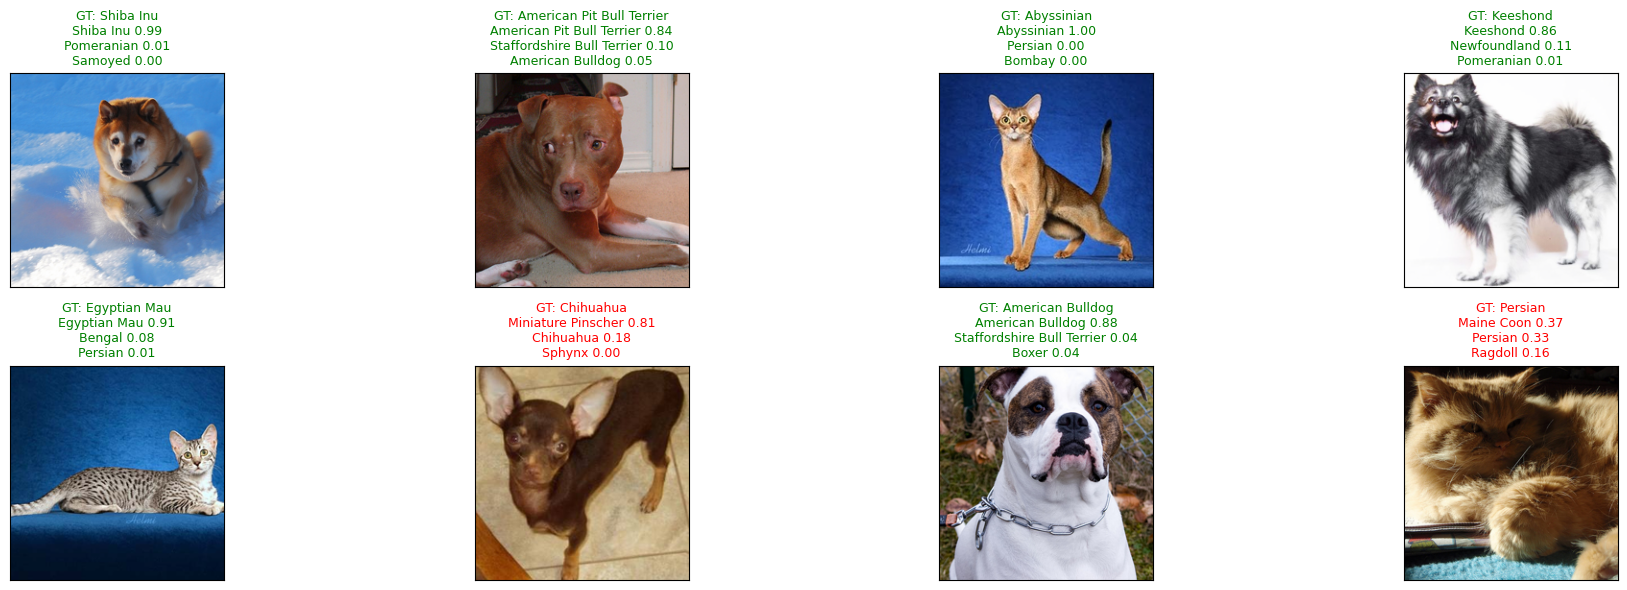

In [36]:
# ✅ 확인 셀
assert zs_acc["C. 과제 맞춤 프롬프트"] > 0.80, "정확도가 80%보다 낮다면 ⑪~⑭를 다시 확인하세요."
print("✅ 통과")

# 예측 예시: 테스트 이미지 8장의 top-3
W_best = build_zeroshot_weights(classnames, templates["C. 과제 맞춤 프롬프트"])
idx = np.random.default_rng(0).choice(len(test_pet), 8, replace=False)
fig = plt.figure(figsize=(20, 6))
for k, i in enumerate(idx):
    img, y = test_pet[i]
    probs = (clip_model.logit_scale.exp() * test_Ie[i:i + 1].to(device) @ W_best).softmax(dim=-1)[0].cpu()
    top = probs.topk(3)
    ax = fig.add_subplot(2, 4, k + 1, xticks=[], yticks=[])
    ax.imshow(im_convert(img, CLIP_MEAN, CLIP_STD))
    title = "\n".join(f"{classnames[j]} {p:.2f}" for p, j in zip(top.values.tolist(), top.indices.tolist()))
    ax.set_title(f"GT: {classnames[y]}\n" + title, fontsize=9, color=("green" if top.indices[0] == y else "red"))
plt.tight_layout(); plt.show()

---
## Part 4. linear probe와 few-shot vs zero-shot (교재 5.3.1 ↔ 논문 3.2절, Figure 6 · 7)

Part 1에서 한 **특성 추출 기법**이 곧 논문의 **linear probe**입니다. 논문 부록 A.3은 CLIP-ViT의 경우 **투영 전 특징 $I_f$** 를 쓰고, scikit-learn의 L-BFGS 로지스틱 회귀(최대 1,000회 반복)를 학습했다고 밝힙니다.
같은 방식으로 **ImageNet ResNet18 특징**과 **CLIP 특징**을 비교하고, 클래스당 라벨이 몇 장 있어야 zero-shot을 따라잡는지 확인합니다.

> 정규화 강도 `C`는 논문처럼 검증셋으로 탐색하지 않고 하나로 고정했습니다(간소화).

In [37]:
# 4-1. ImageNet으로 사전 학습된 ResNet18의 512차원 특징 추출 (37개 품종, 데이터 확장 없이)
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()                     # TODO ⑮ 분류기를 떼어 내고 512차원 특징만 출력
backbone = backbone.to(device).eval()

rn_train = torchvision.datasets.OxfordIIITPet(data_root, split="trainval", target_types="category", transform=test_transform)
rn_test = torchvision.datasets.OxfordIIITPet(data_root, split="test", target_types="category", transform=test_transform)

@torch.no_grad()
def extract_resnet_features(dataset, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    feats, ys = [], []
    for x, y in loader:
        feats.append(backbone(x.to(device)).cpu()); ys.append(y)
    return torch.cat(feats), torch.cat(ys)

rn_train_X, rn_train_y = extract_resnet_features(rn_train)
rn_test_X, rn_test_y = extract_resnet_features(rn_test)
assert rn_train_X.shape[1] == 512
print("ResNet18 특징:", tuple(rn_train_X.shape), "✅")

ResNet18 특징: (3680, 512) ✅


In [38]:
# 4-2. linear probe: 고정된 특징 위에 로지스틱 회귀만 학습 (논문 부록 A.3)
from sklearn.linear_model import LogisticRegression

def linear_probe(train_X, train_y, test_X, test_y, C=0.316):
    clf = LogisticRegression(C=C, max_iter=1000)
    clf.fit(train_X.numpy(), train_y.numpy())      # TODO ⑯ 학습 특징과 라벨로 학습
    return clf.score(test_X.numpy(), test_y.numpy())

acc_rn_lp = linear_probe(rn_train_X, rn_train_y, rn_test_X, rn_test_y)
acc_clip_lp = linear_probe(train_If, train_y, test_If, test_y)
acc_clip_zs = zs_acc["C. 과제 맞춤 프롬프트"]

print(f"ResNet18 (ImageNet) linear probe : {acc_rn_lp:.4f}")
print(f"CLIP ViT-B/32       linear probe : {acc_clip_lp:.4f}   (논문 Table 10: 0.900)")
print(f"CLIP ViT-B/32       zero-shot    : {acc_clip_zs:.4f}   (논문 Table 11: 0.870)")

ResNet18 (ImageNet) linear probe : 0.9002
CLIP ViT-B/32       linear probe : 0.8959   (논문 Table 10: 0.900)
CLIP ViT-B/32       zero-shot    : 0.8744   (논문 Table 11: 0.870)


  1-shot | CLIP 0.3858 | ResNet18 0.5946
  2-shot | CLIP 0.5162 | ResNet18 0.7114
  4-shot | CLIP 0.6571 | ResNet18 0.8044
  8-shot | CLIP 0.7608 | ResNet18 0.8387
 16-shot | CLIP 0.8243 | ResNet18 0.8627
 32-shot | CLIP 0.8625 | ResNet18 0.8855
 64-shot | CLIP 0.8873 | ResNet18 0.8909


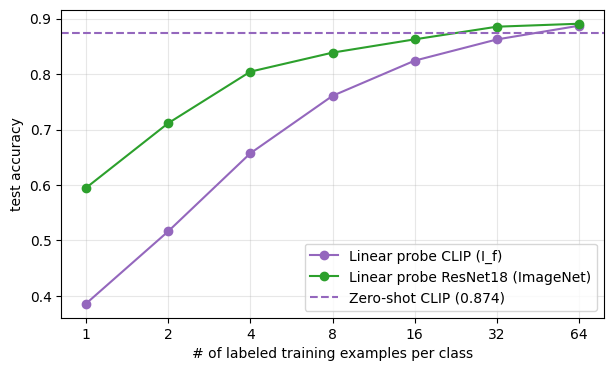

In [39]:
# 4-3. few-shot vs zero-shot (논문 Figure 6 · 7의 축소판)
def sample_k_shot(y, k, seed):
    rng = np.random.default_rng(seed)
    idx = []
    for c in np.unique(y):
        candidates = np.where(y == c)[0]
        idx.extend(rng.choice(candidates, size=k, replace=False))
    return np.array(idx)

shots = [1, 2, 4, 8, 16, 32, 64]
few_shot = {"CLIP": [], "ResNet18": []}
for k in shots:
    accs_clip, accs_rn = [], []
    for seed in range(3):                                        # 무작위 샘플링 3회 평균
        idx =sample_k_shot(train_y.numpy(), k, seed)        # TODO ⑰ 클래스당 k장 뽑기
        accs_clip.append(linear_probe(train_If[idx], train_y[idx], test_If, test_y))
        accs_rn.append(linear_probe(rn_train_X[idx], rn_train_y[idx], rn_test_X, rn_test_y))
    few_shot["CLIP"].append(np.mean(accs_clip)); few_shot["ResNet18"].append(np.mean(accs_rn))
    print(f"{k:>3d}-shot | CLIP {few_shot['CLIP'][-1]:.4f} | ResNet18 {few_shot['ResNet18'][-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(shots, few_shot["CLIP"], "o-", color="tab:purple", label="Linear probe CLIP (I_f)")
plt.plot(shots, few_shot["ResNet18"], "o-", color="tab:green", label="Linear probe ResNet18 (ImageNet)")
plt.axhline(acc_clip_zs, ls="--", color="tab:purple", label=f"Zero-shot CLIP ({acc_clip_zs:.3f})")
plt.xscale("log", base=2); plt.xticks(shots, shots)
plt.xlabel("# of labeled training examples per class"); plt.ylabel("test accuracy")
plt.legend(); plt.grid(alpha=.3); plt.show()

In [40]:
# ✅ 확인 셀
assert acc_clip_lp > acc_clip_zs - 0.05 and acc_clip_lp > 0.8
assert len(few_shot["CLIP"]) == len(shots)
print("✅ 통과")

✅ 통과


---
## Part 5. 서술형 문제 (논문 2 · 3장)

**5-1.** CLIP이 캡션을 그대로 생성하는 대신 대조 학습을 택한 이유를 논문 Figure 2를 근거로 설명하세요.

**답:**

Figure 2에서 캡션을 생성하는 방식은 bag-of-words를 예측하는 방식보다 ImageNet zero-shot 학습이 3배 느렸다. 또 같은 bag-of-words 인코딩에서 예측을 대조 학습으로 바꾸자 효율이 추가로 4배 좋아졌다. 이미지에 붙는 설명은 다양해서 정확한 단어를 생성하기 어렵지만, 배치 안에서 이미지와 짝이 되는 텍스트를 고르는 것은 상대적으로 쉽다. 그래서 CLIP은 대규모 학습에 더 효율적인 대조 학습을 선택했다.

**5-2.** zero-shot CLIP 분류기가 '선형 분류기'라는 말의 의미를 가중치 $W$, bias, 정규화의 관점에서 설명하고, Part 1의 `nn.Linear(512, 2)`와 무엇이 같고 무엇이 다른지 쓰세요.

**답:**

둘 다 특징 벡터에 가중치를 곱해 클래스별 점수를 계산하는 선형 분류기다. CLIP은 이미지 임베딩과 가중치 역할을 하는 텍스트 임베딩을 모두 L2 정규화하고, bias 없이 점수에 1/τ를 곱한다. 가장 큰 차이는 가중치를 얻는 방법이다. nn.Linear(512, 2)는 라벨 데이터로 가중치와 bias를 학습하지만, zero-shot CLIP은 클래스 설명을 텍스트 인코더에 넣어 가중치를 만든다. 따라서 새로운 클래스도 설명만 바꾸면 추가 학습 없이 분류할 수 있다.

**5-3.** 여러분의 실험에서 zero-shot CLIP은 클래스당 몇 장의 라벨로 학습한 linear probe와 비슷했나요? 논문 Figure 6(평균적으로 4-shot과 비슷)·Figure 7(Oxford Pets는 약 48장)과 비교하고, 차이가 난다면 이유를 추측하세요.

**답:**

실험에서 linear probe가 zero-shot과 비슷해진 시점은 클래스당 [실험에서 확인한 장수]장이었다. 논문에서는 Figure 6의 여러 데이터셋 평균이 약 4-shot과 비슷했고, Figure 7에서는 Oxford Pets에 약 48장이 필요하다고 추정했다. 실험과 차이가 난다면 모델 크기, 분류기의 하이퍼파라미터 설정, 뽑힌 학습 이미지의 차이 때문일 수 있다. 적은 수의 이미지로 개념을 배우는 것보다 자연어로 개념을 직접 지정하는 방식이 더 유리할 수 있다는 점을 보여 준다.

**5-4.** 논문은 표현을 평가할 때 왜 fine-tuning(교재 5.3.2 미세 조정) 대신 linear probe(교재 5.3.1 특성 추출)를 택했나요? (3.2절)

**답:**

Fine-tuning은 데이터셋에 맞춰 특징 추출기까지 바꾸기 때문에, 사전학습된 표현 자체의 부족한 부분을 가릴 수 있다. 반면 linear probe는 특징 추출기를 고정하므로 기존 표현에 분류에 필요한 정보가 얼마나 담겨 있는지 평가하기 좋다. 또 zero-shot 분류기와 구조가 비슷해 비교하기 쉽고, 66개 모델과 27개 데이터셋을 평가할 때도 fine-tuning보다 설정이 단순해 공정하게 비교하기 좋다.


**5-5 (도전).** 논문 3.3절은 CLIP 특징에 ImageNet 로지스틱 회귀를 붙이면 ImageNet 정확도는 9.2%p 오르지만 분포 이동 데이터셋 평균은 오히려 조금 떨어진다고 보고합니다. Part 1의 ResNet18 분류기와 Part 3의 zero-shot CLIP 중, 스케치나 만화 속 개·고양이에 더 강할 것은 어느 쪽일지 근거와 함께 예상해 보세요. (직접 그린 그림이나 만화 이미지를 업로드해 확인해 보면 더 좋습니다.)

**답:**

스케치나 만화 속 개·고양이는 zero-shot CLIP이 더 잘 분류할 것으로 예상한다. 논문에서 zero-shot CLIP은 ImageNet 정확도가 비슷한 기존 모델보다 스케치나 그림처럼 분포가 달라진 이미지에서 높은 성능을 보였다. Part 1의 ResNet18 분류기는 학습에 사용한 실제 사진의 특징에 맞춰질 수 있지만, CLIP은 더 다양한 이미지–텍스트 데이터로 사전학습했기 때문이다. 다만 이것이 자연어 감독만의 효과라고 단정하기는 어렵고, 실제 실험에서도 CLIP이 항상 더 좋다고 보장할 수는 없다.

---
### 참고 자료
- 논문: [arXiv:2103.00020](https://arxiv.org/abs/2103.00020) — 2.3절(학습 방법), 3.1절(zero-shot), 3.2절(linear probe), 3.3절(robustness), 부록 A.3(linear probe 설정), 부록 F(하이퍼파라미터)
- d2l.ai: [4.1 Softmax Regression](https://d2l.ai/chapter_linear-classification/softmax-regression.html) (cross-entropy) · [14.2 Fine-Tuning](https://d2l.ai/chapter_computer-vision/fine-tuning.html) · [11.8 Transformers for Vision](https://d2l.ai/chapter_attention-mechanisms-and-transformers/vision-transformer.html)
- 교재: 《딥러닝 파이토치 교과서》 5.3.1 특성 추출 기법, 5.3.2 미세 조정 기법
- 공식 코드와 모델 카드: [github.com/openai/CLIP](https://github.com/openai/CLIP)